# 24. 행동 스티커 만들기 — StackedHourglass vs SimpleBaseline

MPII Human Pose Dataset 위에서 **StackedHourglass**와 **SimpleBaseline**을
동일한 조건으로 학습시키고 비교한다. 이 노트북 하나로 데이터 다운로드부터
학습·비교까지 전부 수행한다.

## 전체 실행 플로우

```
                ┌──────────────────────────────────────────────┐
                │ 1. 데이터 다운로드                             │
                │    images/ + train.json + validation.json     │
                └──────────────────────┬───────────────────────┘
                                       │
               ┌───────────────────────▼───────────────────────┐
               │ 2. 전처리  Preprocessor                        │
               │    crop_roi      사람 영역만 crop (+margin)     │
               │    resize        256×256, [-1,1] 정규화         │
               │    make_heatmaps 좌표 → (16,64,64) 가우시안     │
               └───────────────────────┬───────────────────────┘
                                       │ build_dataloader
                                       │ num_workers / pin_memory / prefetch
                                       ▼
                    ┌──────────────────────────────────┐
                    │ 4. Trainer  (두 모델이 공유)       │
                    │    weighted MSE (label>0 → ×82)   │
                    │    Adam + AMP + best checkpoint   │
                    └──────┬───────────────────┬───────┘
                           │                   │
         ┌─────────────────▼───┐   ┌───────────▼──────────────────┐
         │ StackedHourglass    │   │ SimpleBaseline                │
         │ hourglass×4         │   │ ResNet50 + deconv×3           │
         │ → heatmap 4장       │   │ → heatmap 1장                 │
         └─────────────────┬───┘   └───────────┬──────────────────┘
                           └─────────┬─────────┘
                                     ▼
                 ┌───────────────────────────────────────┐
                 │ 5. 평가                                │
                 │    decode_heatmap  argmax + 0.25px 보정│
                 │    compare_models  나란히 시각화        │
                 │    plot_history    loss 곡선 비교       │
                 └───────────────────────────────────────┘
```

두 모델 모두 `forward()`가 **heatmap 리스트**를 반환하도록 규약을 통일했다.
그래서 STEP 2에서 실제로 바뀌는 것은 **모델 선언 한 줄**뿐이고,
나머지 조건이 동일하다는 것을 코드로 보장할 수 있다.

## 목차

| 절 | 내용 |
| --- | --- |
| 1 | 환경 확인 및 데이터 다운로드 |
| 2 | 데이터 파이프라인 + 속도 벤치마크 (루브릭 1) |
| 3 | STEP 1 — SimpleBaseline 구현 (루브릭 2) |
| 4 | STEP 2 — 모델만 바꿔 학습 |
| 5 | STEP 3 — 두 모델 비교 (루브릭 3) |
| 6 | 디버깅 기록 및 추가 실험 |
| 7 | 회고 |

## 코랩에서 실행할 때

1. **런타임 → 런타임 유형 변경 → GPU (T4 이상)** 로 먼저 바꾼다. CPU 로는 학습이 사실상 불가능하다.
2. 이미지 12GB 는 `/content` (런타임 로컬 디스크)에 받는다. **세션이 끊기면 사라지므로**
   다음 세션에서는 1-2 절을 다시 실행해야 한다.
3. 체크포인트와 학습 이력만 Google Drive 에 저장한다 (`SAVE_TO_DRIVE = True`).
   학습 결과가 남아 있으면 5절에서 `History.from_json(...)` 으로 비교만 다시 할 수 있다.
4. 런타임이 끊기면 이미지를 다시 받아야 하므로 체크포인트를 Drive 에 남긴다.
   실행 기록(L4 GPU, vCPU 12): 다운로드 31분 + Hourglass 25분 + SimpleBaseline
   8분 = 약 65분으로 한 세션에 들어갔다. 무료 T4 런타임은 더 오래 걸리므로
   모델을 나눠 학습하는 편이 안전하다.


---

## 1. 환경 확인 및 데이터 다운로드

### 1-1. 라이브러리 버전 확인

In [1]:
import sys

import numpy as np
import PIL
import torch
import torchvision

print("python      :", sys.version.split()[0])
print("torch       :", torch.__version__)
print("torchvision :", torchvision.__version__)
print("numpy       :", np.__version__)
print("Pillow      :", PIL.__version__)
print("CUDA        :", torch.cuda.is_available(),
      torch.cuda.get_device_name(0) if torch.cuda.is_available() else "")

python      : 3.13.15
torch       : 2.11.0+cu128
torchvision : 0.26.0+cu128
numpy       : 2.1.3
Pillow      : 11.3.0
CUDA        : True NVIDIA L4


### 1-2. MPII 데이터셋 다운로드

> ⚠️ **이미지 파일이 12GB가 넘는다.** 네트워크 상황에 따라 수십 분~수 시간이
> 걸리므로 미리 실행해 두는 것을 권한다. `wget -c` 를 써서 중간에 끊겨도
> 다시 실행하면 이어받는다.

annotation 은 원본이 `.mat` 파일이라 파이썬에서 다루기 불편해서,
미리 json 으로 변환된 파일을 받는다.

In [2]:
import os
import shutil

IS_COLAB = "google.colab" in sys.modules

# 코랩은 /content 가 런타임 로컬 디스크다. 세션이 끊기면 전부 사라지므로
# 12GB 이미지는 여기에 두고, 용량이 작은 체크포인트만 Drive 에 남긴다.
if IS_COLAB:
    PROJECT_PATH = "/content/mpii"
else:
    PROJECT_PATH = os.path.expanduser("~/aiffel/mpii")

IMAGE_PATH = os.path.join(PROJECT_PATH, "images")
ANNO_PATH = os.path.join(PROJECT_PATH, "mpii_human_pose_v1_u12_2")
TRAIN_JSON = os.path.join(ANNO_PATH, "train.json")
VALID_JSON = os.path.join(ANNO_PATH, "validation.json")

# ---- 체크포인트 저장 위치 --------------------------------------------------
# True 로 두면 Google Drive 에 저장해 런타임이 끊겨도 학습 결과가 남는다.
# (체크포인트 + 이력만 저장하므로 수백 MB 수준. 이미지는 Drive 에 넣지 않는다)
SAVE_TO_DRIVE = True

if IS_COLAB and SAVE_TO_DRIVE:
    from google.colab import drive

    drive.mount("/content/drive")
    MODEL_PATH = "/content/drive/MyDrive/mpii_models"
else:
    MODEL_PATH = os.path.join(PROJECT_PATH, "models")

for path in (PROJECT_PATH, ANNO_PATH, MODEL_PATH):
    os.makedirs(path, exist_ok=True)

print("IS_COLAB     :", IS_COLAB)
print("PROJECT_PATH :", PROJECT_PATH)
print("MODEL_PATH   :", MODEL_PATH)
print()
total, used, free = shutil.disk_usage(PROJECT_PATH)
print(f"디스크 여유 공간: {free / 1e9:.1f} GB  (이미지 압축 해제에 약 25GB 필요)")

Mounted at /content/drive
IS_COLAB     : True
PROJECT_PATH : /content/mpii
MODEL_PATH   : /content/drive/MyDrive/mpii_models

디스크 여유 공간: 202.2 GB  (이미지 압축 해제에 약 25GB 필요)


In [3]:
%%time
# 이미지 (약 12GB) — 이미 받아뒀다면 건너뛴다
IMAGE_TAR = os.path.join(PROJECT_PATH, "mpii_human_pose_v1.tar.gz")

if os.path.isdir(IMAGE_PATH) and len(os.listdir(IMAGE_PATH)) > 1000:
    print("이미지가 이미 준비되어 있습니다:", IMAGE_PATH)
else:
    # -c 옵션: 중간에 끊겨도 다시 실행하면 이어받는다
    !wget -c -P "$PROJECT_PATH" https://datasets.d2.mpi-inf.mpg.de/andriluka14cvpr/mpii_human_pose_v1.tar.gz
    !tar -xf "$IMAGE_TAR" -C "$PROJECT_PATH"
    # 압축을 푼 뒤 tar 는 지운다. 코랩 디스크에서 12GB 를 그냥 되찾는 셈이다.
    os.remove(IMAGE_TAR)
    print("압축 해제 완료 (tar 삭제)")

--2026-09-07 03:17:09--  https://datasets.d2.mpi-inf.mpg.de/andriluka14cvpr/mpii_human_pose_v1.tar.gz
Resolving datasets.d2.mpi-inf.mpg.de (datasets.d2.mpi-inf.mpg.de)... 139.19.206.177
Connecting to datasets.d2.mpi-inf.mpg.de (datasets.d2.mpi-inf.mpg.de)|139.19.206.177|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 12088943206 (11G) [application/x-gzip]
Saving to: ‘/content/mpii/mpii_human_pose_v1.tar.gz’

mpii_human_pose_v1. 100%[===================>]  11.26G  2.70MB/s    in 29m 53s 

2026-09-07 03:47:04 (6.43 MB/s) - ‘/content/mpii/mpii_human_pose_v1.tar.gz’ saved [12088943206/12088943206]

압축 해제 완료 (tar 삭제)
CPU times: user 7.8 s, sys: 3 s, total: 10.8 s
Wall time: 31min 33s


In [4]:
# annotation json (수 MB)
for name in ("train.json", "validation.json"):
    target = os.path.join(ANNO_PATH, name)
    if os.path.exists(target):
        print("이미 있음:", name)
        continue
    !wget -q -O "$target" "https://d3s0tskafalll9.cloudfront.net/media/documents/$name"
    print("다운로드 완료:", name)

다운로드 완료: train.json
다운로드 완료: validation.json


In [5]:
# 준비 상태 확인
import json as _json

assert os.path.isdir(IMAGE_PATH), f"이미지 폴더가 없습니다: {IMAGE_PATH}"
n_images = len(os.listdir(IMAGE_PATH))

with open(TRAIN_JSON) as f:
    n_train = len(_json.load(f))
with open(VALID_JSON) as f:
    n_val = len(_json.load(f))

print(f"이미지 파일   : {n_images:,} 장")
print(f"train 샘플    : {n_train:,} 건")
print(f"validation 샘플: {n_val:,} 건")

이미지 파일   : 24,984 장
train 샘플    : 22,246 건
validation 샘플: 2,958 건


---

## 2. 데이터 파이프라인

### 2-1. 공통 상수

MPII 는 관절 16개를 쓴다. 인덱스와 뼈대 연결 정보를 여기서 한 번만 정의하고
학습·시각화 전체에서 재사용한다.

In [6]:
from __future__ import annotations

import io
import json
import math
import time
from dataclasses import dataclass, field
from typing import Dict, List, Optional, Sequence, Tuple

import matplotlib.pyplot as plt
import torch.nn as nn
from PIL import Image
from torch.utils.data import DataLoader, Dataset

IMAGE_SIZE = (256, 256)    # (H, W) — 32의 배수여야 ResNet 이 정확히 1/32 로 떨어진다
HEATMAP_SIZE = (64, 64)    # (H, W) — 입력의 1/4
NUM_HEATMAP = 16           # MPII 관절 개수

(R_ANKLE, R_KNEE, R_HIP, L_HIP, L_KNEE, L_ANKLE, PELVIS, THORAX,
 UPPER_NECK, HEAD_TOP, R_WRIST, R_ELBOW, R_SHOULDER, L_SHOULDER,
 L_ELBOW, L_WRIST) = range(16)

JOINT_NAMES = [
    "r_ankle", "r_knee", "r_hip", "l_hip", "l_knee", "l_ankle",
    "pelvis", "thorax", "upper_neck", "head_top",
    "r_wrist", "r_elbow", "r_shoulder", "l_shoulder", "l_elbow", "l_wrist",
]

MPII_BONES: List[Tuple[int, int]] = [
    (R_ANKLE, R_KNEE), (R_KNEE, R_HIP), (R_HIP, PELVIS),
    (L_HIP, PELVIS), (L_HIP, L_KNEE), (L_KNEE, L_ANKLE),
    (PELVIS, THORAX), (THORAX, UPPER_NECK), (UPPER_NECK, HEAD_TOP),
    (R_WRIST, R_ELBOW), (R_ELBOW, R_SHOULDER), (THORAX, R_SHOULDER),
    (THORAX, L_SHOULDER), (L_SHOULDER, L_ELBOW), (L_ELBOW, L_WRIST),
]

torch.backends.cudnn.benchmark = True   # 입력 크기가 고정이라 알고리즘 캐싱이 유리
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", DEVICE)

device: cuda


### 2-2. 전처리 — Preprocessor

`crop → resize → 정규화 → heatmap 생성` 을 담당한다.
좌표를 그대로 회귀하지 않고 heatmap 으로 바꾸는 이유는, 사람이 찍은 라벨
자체가 매번 몇 픽셀씩 흔들리기 때문이다. 흔들림을 확률 분포로 흡수하면
학습이 안정적이고 성능도 좋아진다 (Tompson et al., NIPS 2014).

In [7]:
def parse_annotation(anno: dict, image_dir: str) -> dict:
    """MPII json 한 건에서 학습에 필요한 필드만 뽑아낸다.

    Args:
        anno: train.json / validation.json 의 원소 하나.
        image_dir: 이미지 파일들이 있는 디렉토리.

    Returns:
        filepath, joints, joints_vis, center, scale 을 담은 dict.
        scale 은 원본 그대로이며, 실제 몸 높이는 scale * 200 이다.
    """
    return {
        "filename": anno["image"],
        "filepath": os.path.join(image_dir, anno["image"]),
        "joints": anno["joints"],
        "joints_vis": anno["joints_vis"],
        "center": anno["center"],
        "scale": anno["scale"],
    }


class Preprocessor:
    """crop → resize → 정규화 → heatmap 생성을 수행하는 transform.

    실습 코드 대비 두 가지를 바꿨다 (근거는 6절 '디버깅 기록' 참고).

    1. JPEG 재인코딩 왕복 제거
       원본은 이미 PIL 로 열린 이미지를 JPEG bytes 로 인코딩한 뒤 다시
       디코딩했다. 샘플마다 불필요한 인코딩 1회 + 디코딩 1회가 붙어
       1 epoch 30분 목표의 걸림돌이 되었다.
    2. crop 밖으로 나간 keypoint 를 invisible 로 강등
       margin 을 랜덤으로 주면 관절이 crop 밖으로 나갈 수 있는데,
       원본은 이를 그대로 heatmap 으로 만들어 경계에 잘못된 정답을 찍었다.

    Args:
        image_size: (H, W) 모델 입력 크기.
        heatmap_size: (H, W) 출력 heatmap 크기.
        num_heatmap: 관절 개수.
        is_train: True 면 margin 을 0.1~0.3 사이에서 랜덤으로 뽑아
            일종의 scale augmentation 으로 사용한다.
        sigma: heatmap 가우시안의 표준편차(픽셀 단위).
    """

    def __init__(self, image_size=IMAGE_SIZE, heatmap_size=HEATMAP_SIZE,
                 num_heatmap=NUM_HEATMAP, is_train=False, sigma=1.0):
        self.image_size = image_size
        self.heatmap_size = heatmap_size
        self.num_heatmap = num_heatmap
        self.is_train = is_train
        self.sigma = sigma

    def crop_roi(self, image: Image.Image, anno: dict, margin: float):
        """사람이 들어있는 영역만 잘라내고 keypoint 를 0~1 로 정규화한다.

        유효한 keypoint 들의 bounding box 에 `body_height * margin` 만큼
        여유를 준 뒤, 이미지 경계를 넘지 않도록 clip 한다.
        유효 keypoint 가 하나도 없는 예외적인 샘플은 center/scale 로 대체한다.

        Returns:
            (crop 된 PIL 이미지, x 배열, y 배열) — 좌표는 crop 기준 0~1.
        """
        img_w, img_h = image.size
        joints = np.asarray(anno["joints"], dtype=np.float32)
        kp_x, kp_y = joints[:, 0], joints[:, 1]
        body_height = anno["scale"] * 200.0

        valid = (kp_x > 0) & (kp_y > 0)
        extra = int(body_height * margin)

        if valid.any():
            xmin, xmax = kp_x[valid].min() - extra, kp_x[valid].max() + extra
            ymin, ymax = kp_y[valid].min() - extra, kp_y[valid].max() + extra
        else:
            cx, cy = anno["center"]
            half = body_height / 2 + extra
            xmin, xmax, ymin, ymax = cx - half, cx + half, cy - half, cy + half

        x0, y0 = int(max(xmin, 0)), int(max(ymin, 0))
        x1, y1 = int(min(xmax, img_w)), int(min(ymax, img_h))
        if x1 - x0 < 2 or y1 - y0 < 2:      # degenerate box 방어
            x0, y0, x1, y1 = 0, 0, img_w, img_h

        cropped = image.crop((x0, y0, x1, y1))
        new_w, new_h = x1 - x0, y1 - y0
        return cropped, (kp_x - x0) / new_w, (kp_y - y0) / new_h

    def make_heatmaps(self, kp_x, kp_y, vis) -> torch.Tensor:
        """정규화된 좌표를 (K, H, W) 가우시안 heatmap 으로 바꾼다.

        Args:
            kp_x, kp_y: crop 기준 0~1 정규화 좌표. (K,)
            vis: 관절별 visibility. 0 이면 heatmap 을 비운다. (K,)

        Returns:
            (K, heatmap_h, heatmap_w) float32 텐서.
        """
        hm_h, hm_w = self.heatmap_size
        heatmaps = torch.zeros((self.num_heatmap, hm_h, hm_w), dtype=torch.float32)

        # 정규화 좌표 → heatmap 픽셀 좌표.
        # x 는 width, y 는 height 로 각각 곱한다 (정사각형이면 티가 안 나지만
        # 비정사각형 heatmap 에서는 x/y 가 뒤바뀐다).
        xs = np.round(kp_x * hm_w).astype(np.int32)
        ys = np.round(kp_y * hm_h).astype(np.int32)

        radius = int(3 * self.sigma)
        size = 2 * radius + 1
        grid = np.arange(size, dtype=np.float32)
        gx, gy = np.meshgrid(grid, grid)
        patch = np.exp(-((gx - radius) ** 2 + (gy - radius) ** 2) / (2 * self.sigma ** 2))
        patch = torch.from_numpy(patch.astype(np.float32))

        for k in range(self.num_heatmap):
            if vis[k] == 0:
                continue
            cx, cy = int(xs[k]), int(ys[k])
            if cx < 0 or cy < 0 or cx >= hm_w or cy >= hm_h:
                continue
            # patch 와 heatmap 이 겹치는 영역만 잘라 붙인다.
            hx0, hx1 = max(0, cx - radius), min(hm_w, cx + radius + 1)
            hy0, hy1 = max(0, cy - radius), min(hm_h, cy + radius + 1)
            px0, px1 = hx0 - (cx - radius), hx1 - (cx - radius)
            py0, py1 = hy0 - (cy - radius), hy1 - (cy - radius)
            heatmaps[k, hy0:hy1, hx0:hx1] = patch[py0:py1, px0:px1]

        return heatmaps

    def __call__(self, image: Image.Image, anno: dict):
        """이미지 한 장을 (image_tensor, heatmaps) 로 변환한다."""
        margin = float(np.random.uniform(0.1, 0.3)) if self.is_train else 0.2
        cropped, kp_x, kp_y = self.crop_roi(image, anno, margin)

        h, w = self.image_size
        cropped = cropped.resize((w, h), Image.BILINEAR)

        arr = np.asarray(cropped, dtype=np.float32) / 127.5 - 1.0   # [-1, 1]
        image_tensor = torch.from_numpy(arr).permute(2, 0, 1).contiguous()

        vis = np.asarray(anno["joints_vis"], dtype=np.float32).copy()
        vis[(kp_x < 0) | (kp_x > 1) | (kp_y < 0) | (kp_y > 1)] = 0   # crop 밖은 제외

        return image_tensor, self.make_heatmaps(kp_x, kp_y, vis)


print("Preprocessor 정의 완료")

Preprocessor 정의 완료


### 2-3. Dataset / DataLoader

GPU 연산보다 디스크 I/O 가 느려 병목이 생긴다. `num_workers` 로 전처리를
여러 프로세스에 분산하고, `prefetch_factor` 로 GPU 가 계산하는 동안 다음
배치를 미리 준비시킨다.

In [8]:
class MPIIDataset(Dataset):
    """MPII json + 이미지 폴더를 읽는 표준 Dataset.

    Args:
        annotation_file: train.json 또는 validation.json 경로.
        image_dir: 이미지 디렉토리.
        transform: Preprocessor 인스턴스. None 이면 (PIL 이미지, anno) 를 그대로 반환.
        limit: 앞에서 N 개만 사용 (디버깅/벤치마크용).
    """

    def __init__(self, annotation_file, image_dir=IMAGE_PATH, transform=None, limit=None):
        with open(annotation_file, "r") as f:
            raw = json.load(f)
        if limit is not None:
            raw = raw[:limit]
        self.annotations = [parse_annotation(a, image_dir) for a in raw]
        self.transform = transform

    def __len__(self):
        return len(self.annotations)

    def __getitem__(self, idx):
        anno = self.annotations[idx]
        image = Image.open(anno["filepath"]).convert("RGB")
        if self.transform is None:
            return image, anno
        return self.transform(image, anno)


def build_dataloader(annotation_file, batch_size=24, is_train=True,
                     num_workers=8, limit=None) -> DataLoader:
    """학습/검증용 DataLoader 를 만든다.

    I/O 병목을 줄이기 위한 옵션들:
        num_workers        CPU 전처리를 여러 프로세스로 분산
        pin_memory         CPU → GPU 복사를 page-locked 메모리로 가속
        persistent_workers epoch 마다 워커를 다시 띄우는 비용 제거
        prefetch_factor    GPU 계산 중 다음 배치를 미리 준비
    """
    dataset = MPIIDataset(annotation_file, IMAGE_PATH,
                          Preprocessor(is_train=is_train), limit=limit)
    kwargs = dict(batch_size=batch_size, shuffle=is_train,
                  num_workers=num_workers, pin_memory=True, drop_last=is_train)
    if num_workers > 0:   # 이 두 옵션은 워커가 있을 때만 유효하다
        kwargs.update(persistent_workers=True, prefetch_factor=4)
    return DataLoader(dataset, **kwargs)


def benchmark_dataloader(loader: DataLoader, num_batches: int = 50) -> Dict[str, float]:
    """데이터 로딩만의 속도를 측정해 1 epoch 예상 시간을 추정한다.

    모델 연산 없이 배치를 꺼내기만 하므로, 여기서 나온 값이
    1 epoch 시간의 하한선이다. 이미 30분을 넘으면 모델을 아무리 빠르게
    만들어도 소용이 없다.
    """
    it = iter(loader)
    next(it)                      # 워커 기동 비용은 측정에서 제외

    start, count = time.time(), 0
    for _ in range(num_batches):
        try:
            next(it)
        except StopIteration:
            break
        count += 1
    elapsed = time.time() - start

    sec_per_batch = elapsed / max(count, 1)
    batch_size = loader.batch_size or 1
    return {
        "sec_per_batch": sec_per_batch,
        "samples_per_sec": batch_size / sec_per_batch,
        "est_epoch_min": sec_per_batch * len(loader) / 60,
    }


print("Dataset / DataLoader 정의 완료")

Dataset / DataLoader 정의 완료


### 2-4. 속도 벤치마크 — 루브릭 1 (1 epoch 30분 이내)

In [9]:
# 코랩 런타임 등급에 따라 vCPU 가 2~12개로 갈린다. 코어 수에 맞춰 자동 설정한다.
NUM_WORKERS = min(os.cpu_count() or 2, 8)
# 16GB GPU 기준. OOM 이 나면 8 로 줄인다.
BATCH_SIZE = 16 if IS_COLAB else 24

print(f"CPU 코어: {os.cpu_count()} -> num_workers={NUM_WORKERS}, batch_size={BATCH_SIZE}")

train_loader = build_dataloader(TRAIN_JSON, BATCH_SIZE, is_train=True,
                                num_workers=NUM_WORKERS)
val_loader = build_dataloader(VALID_JSON, BATCH_SIZE, is_train=False,
                              num_workers=NUM_WORKERS)

print(f"train: {len(train_loader.dataset):,} samples / {len(train_loader)} batches")
print(f"val  : {len(val_loader.dataset):,} samples / {len(val_loader)} batches")

CPU 코어: 12 -> num_workers=8, batch_size=16
train: 22,246 samples / 1390 batches
val  : 2,958 samples / 185 batches


In [10]:
stats = benchmark_dataloader(train_loader, num_batches=50)

print(f"batch 1개당       : {stats['sec_per_batch'] * 1000:.0f} ms")
print(f"초당 샘플 수       : {stats['samples_per_sec']:.0f} samples/s")
print(f"1 epoch 예상(로딩) : {stats['est_epoch_min']:.1f} 분")
print()
print("→ 루브릭 기준 30분 이내 충족"
      if stats["est_epoch_min"] < 30 else "→ 기준 초과: num_workers 를 늘려볼 것")

batch 1개당       : 43 ms
초당 샘플 수       : 370 samples/s
1 epoch 예상(로딩) : 1.0 분

→ 루브릭 기준 30분 이내 충족


In [26]:
!apt-get -qq install -y fonts-nanum > /dev/null
import matplotlib.font_manager as fm
fm.fontManager.addfont('/usr/share/fonts/truetype/nanum/NanumGothic.ttf')
plt.rc('font', family='NanumGothic')
plt.rc('axes', unicode_minus=False)

image  batch: (16, 3, 256, 256)
heatmap batch: (16, 16, 64, 64)


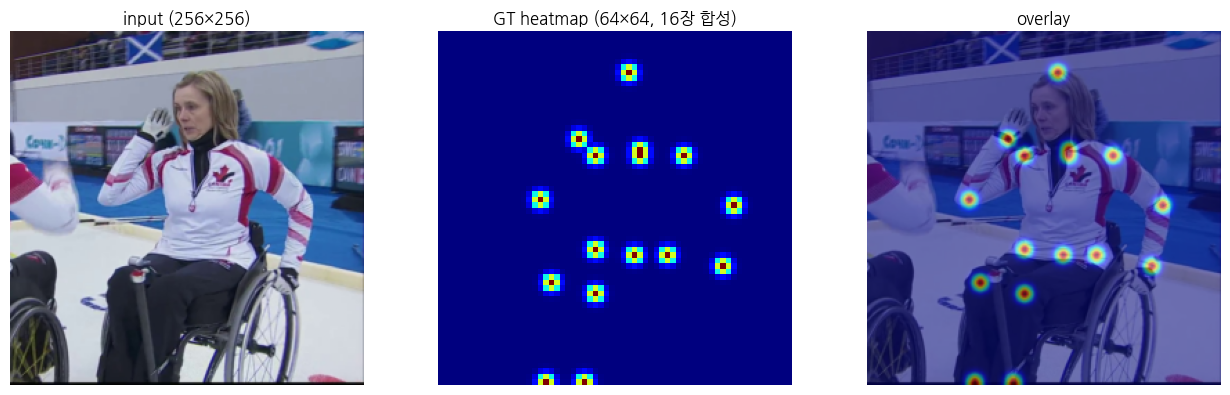

In [27]:
# 전처리 결과 확인 — 라벨(heatmap)이 관절 위치에 제대로 찍혔는지 눈으로 검증
images, heatmaps = next(iter(val_loader))
print("image  batch:", tuple(images.shape))     # (B, 3, 256, 256)
print("heatmap batch:", tuple(heatmaps.shape))  # (B, 16, 64, 64)

img = (images[0].permute(1, 2, 0).numpy() + 1) / 2      # [-1,1] → [0,1]
merged = heatmaps[0].max(dim=0).values.numpy()          # 16장을 겹쳐 하나로
upscaled = np.array(Image.fromarray((merged * 255).astype(np.uint8)).resize((256, 256)))

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
axes[0].imshow(img);                    axes[0].set_title("input (256×256)")
axes[1].imshow(merged, cmap="jet");     axes[1].set_title("GT heatmap (64×64, 16장 합성)")
axes[2].imshow(img); axes[2].imshow(upscaled, cmap="jet", alpha=0.5)
axes[2].set_title("overlay")
for ax in axes:
    ax.axis("off")
plt.tight_layout(); plt.show()

---

## 3. STEP 1 — SimpleBaseline 구현

Xiao et al., *Simple Baselines for Human Pose Estimation and Tracking*, ECCV 2018.

```
입력 (B,3,256,256)
  └ encoder : torchvision ResNet50 에서 avgpool/fc 제거   → (B,2048,8,8)
  └ neck    : 1×1 conv 로 2048 → 256                      → (B,256,8,8)
  └ decoder : (ConvTranspose2d 4×4 s2 + BN + ReLU) × 3     → (B,256,64,64)
  └ head    : 1×1 conv                                     → (B,16,64,64)
```

**설계에서 신경 쓴 두 가지**

1. `forward()` 가 **길이 1인 리스트**를 반환한다.
   Hourglass 는 intermediate supervision 때문에 heatmap 을 4장 내놓고,
   `Trainer.compute_loss()` 는 그 리스트를 순회한다. SimpleBaseline 도 같은
   규약을 따르면 학습·평가 코드를 한 줄도 건드릴 필요가 없다.
2. **encoder 는 초기화하지 않는다.**
   ImageNet 가중치를 살려야 하므로 새로 붙인 neck/decoder/head 만
   std=0.001 로 초기화한다. heatmap 은 대부분 0인 희소한 타깃이라
   출력이 0 근처에서 시작해야 학습 초반이 안정적이다.

In [12]:
import torchvision.models as tv_models

# torchvision 버전에 따라 pretrained= / weights= 인자가 갈리므로 한 번만 분기
_TV_NEW_API = hasattr(tv_models, "ResNet50_Weights")

_BACKBONE_OUT_CHANNELS = {
    "resnet18": 512, "resnet34": 512,
    "resnet50": 2048, "resnet101": 2048, "resnet152": 2048,
}


def build_backbone(name: str, pretrained: bool) -> nn.Module:
    """torchvision ResNet 에서 분류 헤드를 떼어낸 feature extractor.

    `list(resnet.children())[:-2]` 로 뒤의 avgpool 과 fc 를 잘라낸다.
    분류용 헤드는 spatial 정보를 전부 뭉개버리는데, pose estimation 은
    '어디에' 관절이 있는지를 알아야 하므로 공간 정보가 살아있는
    feature map 이 필요하기 때문이다.

    Returns:
        (B, 3, H, W) → (B, C, H/32, W/32) 를 수행하는 nn.Sequential.
    """
    if name not in _BACKBONE_OUT_CHANNELS:
        raise ValueError(f"지원하지 않는 backbone: {name}")
    if _TV_NEW_API:
        resnet = getattr(tv_models, name)(weights="DEFAULT" if pretrained else None)
    else:
        resnet = getattr(tv_models, name)(pretrained=pretrained)
    return nn.Sequential(*list(resnet.children())[:-2])


class DeconvHead(nn.Module):
    """(ConvTranspose2d + BatchNorm + ReLU) 를 num_layers 번 쌓은 decoder.

    공식 구현의 기본값을 따른다: 레이어 3개, 필터 256개, 커널 4×4, stride 2.
    kernel_size=4, stride=2, padding=1 조합은 feature map 을 정확히 2배로 키운다.
    (출력 = (입력-1)*stride - 2*padding + kernel = 2*입력)
    따라서 3번 통과하면 8×8 → 64×64 가 되어 heatmap 해상도와 일치한다.
    """

    def __init__(self, in_channels, num_layers=3, num_filters=256, kernel_size=4):
        super().__init__()
        if kernel_size not in (2, 3, 4):
            raise ValueError("kernel_size 는 2, 3, 4 중 하나여야 합니다.")
        padding, output_padding = {4: (1, 0), 3: (1, 1), 2: (0, 0)}[kernel_size]

        layers, channels = [], in_channels
        for _ in range(num_layers):
            layers += [
                nn.ConvTranspose2d(channels, num_filters, kernel_size=kernel_size,
                                   stride=2, padding=padding,
                                   output_padding=output_padding, bias=False),
                nn.BatchNorm2d(num_filters, momentum=0.1),
                nn.ReLU(inplace=True),
            ]
            channels = num_filters

        self.layers = nn.Sequential(*layers)
        self.out_channels = channels

    def forward(self, x):
        return self.layers(x)


class SimpleBaseline(nn.Module):
    """ResNet encoder + 3단 deconv decoder 로 heatmap 을 회귀하는 모델.

    Args:
        backbone: 사용할 ResNet 이름.
        num_heatmap: 출력 heatmap 개수. MPII 는 16, COCO 는 17.
        pretrained: backbone 의 ImageNet 사전학습 가중치 사용 여부.
        return_list: True 면 [heatmap] 형태의 리스트를 반환한다.
            StackedHourglass 와 동일한 인터페이스를 유지해 Trainer 를
            공유하기 위한 스위치이며, 기본값 True 를 권장한다.

    Shape:
        입력 (B, 3, 256, 256) → 출력 [(B, num_heatmap, 64, 64)]
    """

    def __init__(self, backbone="resnet50", num_heatmap=NUM_HEATMAP,
                 num_deconv_layers=3, num_deconv_filters=256,
                 deconv_kernel=4, pretrained=True, return_list=True):
        super().__init__()
        self.return_list = return_list
        self.num_heatmap = num_heatmap

        self.encoder = build_backbone(backbone, pretrained)
        encoder_out = _BACKBONE_OUT_CHANNELS[backbone]

        # neck: 2048 채널을 그대로 deconv 에 넣으면 파라미터가 과하게 커진다.
        self.neck = nn.Conv2d(encoder_out, num_deconv_filters, kernel_size=1, bias=False)
        self.decoder = DeconvHead(num_deconv_filters, num_deconv_layers,
                                  num_deconv_filters, deconv_kernel)
        # head: keypoint 하나당 heatmap 한 장. 1×1 이라 위치 정보를 섞지 않는다.
        self.final_layer = nn.Conv2d(self.decoder.out_channels, num_heatmap, kernel_size=1)

        self._init_weights()

    def _init_weights(self):
        """encoder 를 제외한 새 레이어만 std=0.001 로 초기화한다."""
        for module in list(self.neck.modules()) + list(self.decoder.modules()):
            if isinstance(module, (nn.Conv2d, nn.ConvTranspose2d)):
                nn.init.normal_(module.weight, std=0.001)
                if module.bias is not None:
                    nn.init.constant_(module.bias, 0)
            elif isinstance(module, nn.BatchNorm2d):
                nn.init.constant_(module.weight, 1)
                nn.init.constant_(module.bias, 0)
        nn.init.normal_(self.final_layer.weight, std=0.001)
        nn.init.constant_(self.final_layer.bias, 0)

    def forward(self, x):
        x = self.encoder(x)             # (B, 2048, H/32, W/32)
        x = self.neck(x)                # (B,  256, H/32, W/32)
        x = self.decoder(x)             # (B,  256, H/4,  W/4)
        heatmap = self.final_layer(x)   # (B,    K, H/4,  W/4)
        return [heatmap] if self.return_list else heatmap


def build_simplebaseline(num_heatmap=NUM_HEATMAP, **kwargs) -> SimpleBaseline:
    """한 줄로 부르기 위한 팩토리 함수."""
    return SimpleBaseline(num_heatmap=num_heatmap, **kwargs)


print("SimpleBaseline 정의 완료")

SimpleBaseline 정의 완료


### 3-1. 비교 대상 — StackedHourglass

실습에서 다룬 모델을 **동일한 입출력 규약**으로 정리한다.
두 모델이 같은 Trainer 와 같은 평가 코드를 공유해야 공정한 비교가 된다.

In [13]:
BN_MOMENTUM = 0.1


class BottleneckBlock(nn.Module):
    """1×1 - 3×3 - 1×1 구조의 pre-activation residual block.

    Hourglass 도식에서 직육면체로 그려진 박스가 전부 이 블록이다.
    가운데 3×3 conv 를 절반 채널에서 수행해 연산량을 줄이고,
    앞뒤 1×1 conv 로 채널을 줄였다 되돌린다.

    Args:
        downsample: 입출력 채널이 다를 때 True. identity 경로에도
            1×1 conv 를 태워 채널 수를 맞춘다.
    """

    def __init__(self, in_channels, filters, downsample=False):
        super().__init__()
        self.downsample = downsample
        if downsample:
            self.downsample_conv = nn.Conv2d(in_channels, filters, kernel_size=1, bias=False)

        half = filters // 2
        self.bn1 = nn.BatchNorm2d(in_channels, momentum=BN_MOMENTUM)
        self.conv1 = nn.Conv2d(in_channels, half, kernel_size=1, bias=False)
        self.bn2 = nn.BatchNorm2d(half, momentum=BN_MOMENTUM)
        self.conv2 = nn.Conv2d(half, half, kernel_size=3, padding=1, bias=False)
        self.bn3 = nn.BatchNorm2d(half, momentum=BN_MOMENTUM)
        self.conv3 = nn.Conv2d(half, filters, kernel_size=1, bias=False)
        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        identity = self.downsample_conv(x) if self.downsample else x
        out = self.conv1(self.relu(self.bn1(x)))
        out = self.conv2(self.relu(self.bn2(out)))
        out = self.conv3(self.relu(self.bn3(out)))
        return out + identity


class HourglassModule(nn.Module):
    """재귀적으로 정의되는 모래시계 모듈.

    Hourglass 는 양파처럼 바깥 껍질을 벗기면 같은 구조가 다시 나온다.
    그래서 order 를 하나씩 줄여가며 자기 자신을 품고,
    order == 1 이 되면 BottleneckBlock 으로 대체해 재귀를 종료한다.

        order=N  ┌ up   branch (해상도 유지) ────────────┐ (+)
                 └ pool → order=N-1 → upsample ─────────┘
    """

    def __init__(self, order, filters, num_residual):
        super().__init__()
        self.order = order

        def stack(n):
            return nn.Sequential(*[BottleneckBlock(filters, filters) for _ in range(n)])

        self.up1 = nn.Sequential(BottleneckBlock(filters, filters), stack(num_residual))
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.low1 = stack(num_residual)
        self.low2 = (HourglassModule(order - 1, filters, num_residual)
                     if order > 1 else stack(num_residual))
        self.low3 = stack(num_residual)
        self.upsample = nn.Upsample(scale_factor=2, mode="nearest")

    def forward(self, x):
        up1 = self.up1(x)
        low = self.low3(self.low2(self.low1(self.pool(x))))
        return self.upsample(low) + up1


class LinearLayer(nn.Module):
    """1×1 conv + BN + ReLU. stack 사이를 잇는 얇은 연결층."""

    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv = nn.Conv2d(in_channels, out_channels, kernel_size=1, bias=False)
        self.bn = nn.BatchNorm2d(out_channels, momentum=BN_MOMENTUM)
        self.relu = nn.ReLU(inplace=True)
        nn.init.kaiming_normal_(self.conv.weight, mode="fan_out", nonlinearity="relu")

    def forward(self, x):
        return self.relu(self.bn(self.conv(x)))


class StackedHourglassNetwork(nn.Module):
    """Hourglass 모듈을 num_stack 개 쌓고 매 stack 마다 heatmap 을 출력한다.

    각 stack 의 heatmap 을 전부 반환하는 이유는 intermediate supervision
    때문이다. 모델이 깊어질수록 학습이 어려워지므로, 중간 heatmap 에도
    ground truth 와의 loss 를 걸어 gradient 가 앞쪽까지 흐르게 한다.
    stack 이 4개면 한 번의 forward 에 loss 가 4번 계산된다.

    Shape:
        입력 (B, 3, 256, 256) → 출력 [(B, K, 64, 64)] × num_stack
    """

    def __init__(self, num_stack=4, num_residual=1, num_heatmap=NUM_HEATMAP, in_channels=3):
        super().__init__()
        self.num_stack = num_stack

        # stem: 256 → 64 로 해상도를 1/4 로 줄여 hourglass 입력을 만든다.
        self.stem = nn.Sequential(
            nn.Conv2d(in_channels, 64, kernel_size=7, stride=2, padding=3, bias=False),
            nn.BatchNorm2d(64, momentum=BN_MOMENTUM),
            nn.ReLU(inplace=True),
            BottleneckBlock(64, 128, downsample=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            BottleneckBlock(128, 128),
            BottleneckBlock(128, 256, downsample=True),
        )

        self.hourglasses = nn.ModuleList()
        self.residuals = nn.ModuleList()
        self.linears = nn.ModuleList()
        self.heatmap_convs = nn.ModuleList()
        self.merge_features = nn.ModuleList()
        self.merge_heatmaps = nn.ModuleList()

        for i in range(num_stack):
            self.hourglasses.append(HourglassModule(4, 256, num_residual))
            self.residuals.append(
                nn.Sequential(*[BottleneckBlock(256, 256) for _ in range(num_residual)]))
            self.linears.append(LinearLayer(256, 256))
            self.heatmap_convs.append(nn.Conv2d(256, num_heatmap, kernel_size=1))
            if i < num_stack - 1:
                self.merge_features.append(nn.Conv2d(256, 256, kernel_size=1))
                self.merge_heatmaps.append(nn.Conv2d(num_heatmap, 256, kernel_size=1))

    def forward(self, x):
        x = self.stem(x)
        outputs = []
        for i in range(self.num_stack):
            feature = self.linears[i](self.residuals[i](self.hourglasses[i](x)))
            heatmap = self.heatmap_convs[i](feature)
            outputs.append(heatmap)
            if i < self.num_stack - 1:
                # 다음 stack 입력 = 현재 feature + 현재 예측을 되먹임
                x = x + self.merge_features[i](feature) + self.merge_heatmaps[i](heatmap)
        return outputs


def build_hourglass(num_heatmap=NUM_HEATMAP, **kwargs) -> StackedHourglassNetwork:
    """한 줄로 부르기 위한 팩토리 함수."""
    return StackedHourglassNetwork(num_heatmap=num_heatmap, **kwargs)


print("StackedHourglass 정의 완료")

StackedHourglass 정의 완료


In [14]:
def count_parameters(model: nn.Module) -> int:
    """학습 가능한 파라미터 개수."""
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


# 출력 규약 검증 — 학습에 시간을 쓰기 전에 여기서 걸러낸다
_sb = build_simplebaseline()
_hg = build_hourglass()
dummy = torch.zeros(2, 3, 256, 256)

with torch.no_grad():
    sb_out, hg_out = _sb(dummy), _hg(dummy)

print("SimpleBaseline : 출력 %d개, shape %s" % (len(sb_out), tuple(sb_out[0].shape)))
print("Hourglass      : 출력 %d개, shape %s" % (len(hg_out), tuple(hg_out[0].shape)))
print()
print(f"SimpleBaseline 파라미터: {count_parameters(_sb):,}")
print(f"Hourglass      파라미터: {count_parameters(_hg):,}")

assert sb_out[0].shape == (2, NUM_HEATMAP, 64, 64)
assert hg_out[0].shape == (2, NUM_HEATMAP, 64, 64)
print("\n두 모델의 출력 규약이 동일 → Trainer 를 그대로 공유할 수 있다.")

del _sb, _hg, sb_out, hg_out, dummy

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 159MB/s]


SimpleBaseline : 출력 1개, shape (2, 16, 64, 64)
Hourglass      : 출력 4개, shape (2, 16, 64, 64)

SimpleBaseline 파라미터: 27,183,696
Hourglass      파라미터: 16,251,392

두 모델의 출력 규약이 동일 → Trainer 를 그대로 공유할 수 있다.


---

## 4. STEP 2 — 모델만 교체해서 학습

### 4-1. Trainer

두 모델이 공유한다. 모델이 heatmap **리스트**를 반환한다는 것만 가정하므로,
stack 이 4개든 1개든 그대로 동작한다.

In [31]:
def make_grad_scaler(enabled: bool):
    """torch 버전에 상관없이 동작하는 GradScaler.

    torch 2.4 부터 `torch.cuda.amp.GradScaler` 가 deprecated 되고
    `torch.amp.GradScaler('cuda', ...)` 로 바뀌었다. 실습 환경의 버전을
    가정하지 않기 위해 새 API 를 먼저 시도하고 없으면 예전 것을 쓴다.
    """
    try:
        return torch.amp.GradScaler("cuda", enabled=enabled)
    except (AttributeError, TypeError):
        return torch.cuda.amp.GradScaler(enabled=enabled)


def autocast_context(enabled: bool):
    """위와 같은 이유로 버전 안전한 autocast 컨텍스트를 반환한다."""
    try:
        return torch.amp.autocast("cuda", enabled=enabled)
    except (AttributeError, TypeError):
        return torch.cuda.amp.autocast(enabled=enabled)


@dataclass
class History:
    """epoch 별 학습 이력. 두 모델의 loss 곡선을 겹쳐 그릴 때 쓴다."""

    name: str
    train_loss: List[float] = field(default_factory=list)
    val_loss: List[float] = field(default_factory=list)
    epoch_sec: List[float] = field(default_factory=list)
    best_checkpoint: Optional[str] = None

    def to_json(self, path):
        with open(path, "w") as f:
            json.dump(self.__dict__, f, indent=2)

    @staticmethod
    def from_json(path) -> "History":
        with open(path) as f:
            return History(**json.load(f))


class Trainer:
    """두 모델이 공유하는 학습 루프.

    Args:
        model: forward 가 List[Tensor] 를 반환하는 nn.Module.
        name: 이력/체크포인트 파일명에 쓰일 식별자.
        learning_rate: Adam 초기 학습률.
        use_amp: mixed precision 사용 여부 (CUDA 에서만 유효).
    """

    def __init__(self, model, name, learning_rate=7e-4, use_amp=True, device=None):
        self.device = device or DEVICE
        self.model = model.to(self.device)
        self.name = name
        self.use_amp = use_amp and self.device.type == "cuda"
        self.optimizer = torch.optim.Adam(self.model.parameters(), lr=learning_rate)
        self.scaler = make_grad_scaler(self.use_amp)
        self.history = History(name=name)
        self.lowest_val_loss = math.inf
        os.makedirs(MODEL_PATH, exist_ok=True)

    def compute_loss(self, outputs, labels):
        """모든 stack 출력의 가중 MSE 를 구해 stack 수로 평균낸다.

        heatmap 은 대부분이 0(배경)이라 그냥 MSE 를 쓰면 '전부 0으로 예측'이
        가장 이득인 해가 된다. 그래서 값이 있는 위치(labels > 0)에
        82배 가중치를 주어 관절 주변을 실제로 맞추도록 만든다.
        """
        weights = (labels > 0).float() * 81 + 1
        loss = torch.zeros((), device=labels.device)
        for output in outputs:
            loss = loss + (((labels - output) ** 2) * weights).mean()
        return loss / len(outputs)

    def _run_epoch(self, loader, train, log_every=100):
        self.model.train(train)
        total, count = 0.0, 0

        for step, (images, labels) in enumerate(loader, start=1):
            images = images.to(self.device, non_blocking=True)
            labels = labels.to(self.device, non_blocking=True)

            with torch.set_grad_enabled(train):
                with autocast_context(self.use_amp):
                    loss = self.compute_loss(self.model(images), labels)

            if train:
                self.optimizer.zero_grad(set_to_none=True)
                self.scaler.scale(loss).backward()
                self.scaler.step(self.optimizer)
                self.scaler.update()

            value = loss.item()
            if not math.isnan(value):
                total += value
                count += 1
            if train and step % log_every == 0:
                print(f"    step {step}/{len(loader)}  loss {total / count:.4f}")

        return total / max(count, 1)

    def run(self, train_loader, val_loader, epochs) -> History:
        """epochs 만큼 학습하고 History 를 반환한다. 최저 val_loss 에서 체크포인트 저장."""
        for epoch in range(1, epochs + 1):
            started = time.time()
            print(f"[{self.name}] epoch {epoch}/{epochs}")

            train_loss = self._run_epoch(train_loader, train=True)
            val_loss = self._run_epoch(val_loader, train=False)
            elapsed = time.time() - started

            self.history.train_loss.append(train_loss)
            self.history.val_loss.append(val_loss)
            self.history.epoch_sec.append(elapsed)
            print(f"    train {train_loss:.4f} | val {val_loss:.4f} | {elapsed / 60:.1f} min")

            if val_loss < self.lowest_val_loss:
                self.lowest_val_loss = val_loss
                path = os.path.join(MODEL_PATH, f"{self.name}-best.pt")
                torch.save(self.model.state_dict(), path)
                self.history.best_checkpoint = path
                print(f"    -> saved {path}")

        self.history.to_json(os.path.join(MODEL_PATH, f"{self.name}-history.json"))
        return self.history


print("Trainer 정의 완료")

Trainer 정의 완료


### 4-2. 학습 실행

아래 두 셀에서 **바뀌는 것은 `model=` 한 줄뿐**이다.
데이터로더, loss, optimizer, epoch 수, 배치 크기가 전부 같아야
결과 차이를 모델 차이로 해석할 수 있다.

In [16]:
EPOCHS = 5          # 루브릭 권장: 5 epoch 이상
LEARNING_RATE = 7e-4

In [32]:
%%time
# --- (a) StackedHourglass -------------------------------------------------
hg_trainer = Trainer(model=build_hourglass(num_heatmap=NUM_HEATMAP),
                     name="hourglass",
                     learning_rate=LEARNING_RATE)
hg_history = hg_trainer.run(train_loader, val_loader, epochs=EPOCHS)

[hourglass] epoch 1/5
    step 100/1390  loss 0.0655
    step 200/1390  loss 0.0570
    step 300/1390  loss 0.0537
    step 400/1390  loss 0.0520
    step 500/1390  loss 0.0508
    step 600/1390  loss 0.0499
    step 700/1390  loss 0.0492
    step 800/1390  loss 0.0486
    step 900/1390  loss 0.0481
    step 1000/1390  loss 0.0477
    step 1100/1390  loss 0.0474
    step 1200/1390  loss 0.0470
    step 1300/1390  loss 0.0467
    train 0.0464 | val 0.0421 | 4.8 min
    -> saved /content/drive/MyDrive/mpii_models/hourglass-best.pt
[hourglass] epoch 2/5
    step 100/1390  loss 0.0419
    step 200/1390  loss 0.0418
    step 300/1390  loss 0.0416
    step 400/1390  loss 0.0415
    step 500/1390  loss 0.0414
    step 600/1390  loss 0.0412
    step 700/1390  loss 0.0411
    step 800/1390  loss 0.0410
    step 900/1390  loss 0.0408
    step 1000/1390  loss 0.0407
    step 1100/1390  loss 0.0406
    step 1200/1390  loss 0.0405
    step 1300/1390  loss 0.0404
    train 0.0403 | val 0.0385 | 4.7 

In [18]:
%%time
# --- (b) SimpleBaseline ---------------------------------------------------
#     위 셀과 비교했을 때 model= 인자 하나만 다르다.
sb_trainer = Trainer(model=build_simplebaseline(num_heatmap=NUM_HEATMAP),
                     name="simplebaseline",
                     learning_rate=LEARNING_RATE)
sb_history = sb_trainer.run(train_loader, val_loader, epochs=EPOCHS)

[simplebaseline] epoch 1/5
    step 100/1390  loss 0.0479
    step 200/1390  loss 0.0464
    step 300/1390  loss 0.0451
    step 400/1390  loss 0.0442
    step 500/1390  loss 0.0435
    step 600/1390  loss 0.0429
    step 700/1390  loss 0.0424
    step 800/1390  loss 0.0420
    step 900/1390  loss 0.0416
    step 1000/1390  loss 0.0413
    step 1100/1390  loss 0.0410
    step 1200/1390  loss 0.0408
    step 1300/1390  loss 0.0405
    train 0.0403 | val 0.0370 | 2.2 min
    -> saved /content/drive/MyDrive/mpii_models/simplebaseline-best.pt
[simplebaseline] epoch 2/5
    step 100/1390  loss 0.0367
    step 200/1390  loss 0.0366
    step 300/1390  loss 0.0364
    step 400/1390  loss 0.0365
    step 500/1390  loss 0.0365
    step 600/1390  loss 0.0365
    step 700/1390  loss 0.0365
    step 800/1390  loss 0.0365
    step 900/1390  loss 0.0364
    step 1000/1390  loss 0.0363
    step 1100/1390  loss 0.0363
    step 1200/1390  loss 0.0363
    step 1300/1390  loss 0.0362
    train 0.0362 | va

---

## 5. STEP 3 — 두 모델 비교

### 5-1. 후처리 및 시각화 함수

In [33]:
def decode_heatmap(heatmaps: torch.Tensor) -> np.ndarray:
    """(K, H, W) heatmap 에서 관절 좌표와 신뢰도를 뽑는다.

    최대값 픽셀을 찾은 뒤, 이웃 픽셀의 기울기 방향으로 0.25 픽셀만큼
    보정한다. heatmap 이 입력의 1/4 해상도라 픽셀 단위 양자화 오차가
    원본에서는 4픽셀에 해당하는데, 이 보정이 그 절반을 줄여준다.

    Returns:
        (K, 3) ndarray. 각 행이 [x, y, score] 이며 x, y 는 0~1 정규화 좌표.
    """
    heatmaps = heatmaps.detach().float().cpu()
    k, h, w = heatmaps.shape
    scores, idx = heatmaps.reshape(k, -1).max(dim=1)

    # 평탄화 인덱스 = row * W + col 이므로 반드시 '열 개수 W' 로 나눈다.
    ys = (idx // w).numpy().astype(np.float32)
    xs = (idx % w).numpy().astype(np.float32)

    hm = heatmaps.numpy()
    for i in range(k):
        px, py = int(xs[i]), int(ys[i])
        if 0 < px < w - 1:
            xs[i] += 0.25 * np.sign(hm[i, py, px + 1] - hm[i, py, px - 1])
        if 0 < py < h - 1:
            ys[i] += 0.25 * np.sign(hm[i, py + 1, px] - hm[i, py - 1, px])

    # x 는 W 로, y 는 H 로 각각 정규화한다 (비정사각형 heatmap 대비).
    return np.stack([xs / w, ys / h, scores.numpy()], axis=1)


@torch.no_grad()
def predict(model, image_path, device=None):
    """이미지 경로 하나를 받아 (PIL 이미지, keypoints) 를 반환한다.

    주의 — 학습/평가와 전처리가 다르다.
        학습과 PCKh 평가는 crop_roi 로 사람 영역만 잘라낸 뒤 256×256 으로
        리사이즈한 입력을 쓴다. 반면 임의의 사진에는 center/scale 정보가
        없어 여기서는 전체 이미지를 그대로 리사이즈한다. 사람이 화면의
        일부만 차지하면 학습 분포와 어긋나 성능이 떨어진다.
        5-3 의 정성 결과는 이 조건에서 본 것이며, 5-4 의 PCKh 수치와
        직접 이어 붙여 해석하면 안 된다.

    Returns:
        (PIL.Image, (K, 3) ndarray) — keypoints 는 [x, y, score], 좌표는 0~1.
    """
    device = device or next(model.parameters()).device
    image = Image.open(image_path).convert("RGB")

    h, w = IMAGE_SIZE
    arr = np.asarray(image.resize((w, h), Image.BILINEAR), dtype=np.float32) / 127.5 - 1.0
    tensor = torch.from_numpy(arr).permute(2, 0, 1).unsqueeze(0).to(device)

    model.eval()
    outputs = model(tensor)
    if not isinstance(outputs, (list, tuple)):
        outputs = [outputs]
    return image, decode_heatmap(outputs[-1][0])   # 마지막 stack 이 최종 예측


def draw_pose(ax, image, keypoints, threshold=0.0, title=""):
    """하나의 축에 관절점과 뼈대를 함께 그린다."""
    arr = np.asarray(image)
    height, width = arr.shape[:2]
    ax.imshow(arr)
    ax.set_title(title)
    ax.axis("off")

    points = keypoints.copy()
    points[:, 0] *= width
    points[:, 1] *= height

    for a, b in MPII_BONES:
        if points[a, 2] < threshold or points[b, 2] < threshold:
            continue
        ax.plot(points[[a, b], 0], points[[a, b], 1], linewidth=3, alpha=0.8)

    keep = points[:, 2] >= threshold
    ax.scatter(points[keep, 0], points[keep, 1], s=18, c="red", zorder=3)


def compare_models(models: Dict[str, nn.Module], image_paths, threshold=0.0):
    """여러 모델의 예측을 같은 이미지에 대해 나란히 그린다 (정성적 비교)."""
    rows, cols = len(image_paths), len(models)
    fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 5 * rows), squeeze=False)
    for r, path in enumerate(image_paths):
        for c, (name, model) in enumerate(models.items()):
            image, keypoints = predict(model, path)
            draw_pose(axes[r][c], image, keypoints, threshold, title=name if r == 0 else "")
    plt.tight_layout(); plt.show()


def plot_history(histories: Sequence[History]):
    """여러 모델의 train/val loss 곡선과 epoch 소요 시간을 겹쳐 그린다."""
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))
    for hist in histories:
        epochs = range(1, len(hist.train_loss) + 1)
        axes[0].plot(epochs, hist.train_loss, marker="o", label=hist.name)
        axes[1].plot(epochs, hist.val_loss, marker="o", label=hist.name)
        axes[2].plot(epochs, [s / 60 for s in hist.epoch_sec], marker="o", label=hist.name)

    for ax, title, ylabel in zip(axes,
                                 ["Train loss", "Validation loss", "Epoch time"],
                                 ["loss", "loss", "minutes"]):
        ax.set_title(title); ax.set_xlabel("epoch"); ax.set_ylabel(ylabel)
        ax.grid(alpha=0.3); ax.legend()
    plt.tight_layout(); plt.show()


print("후처리/시각화 함수 정의 완료")

후처리/시각화 함수 정의 완료


### 5-2. 학습 진행 경과 (정량 비교)

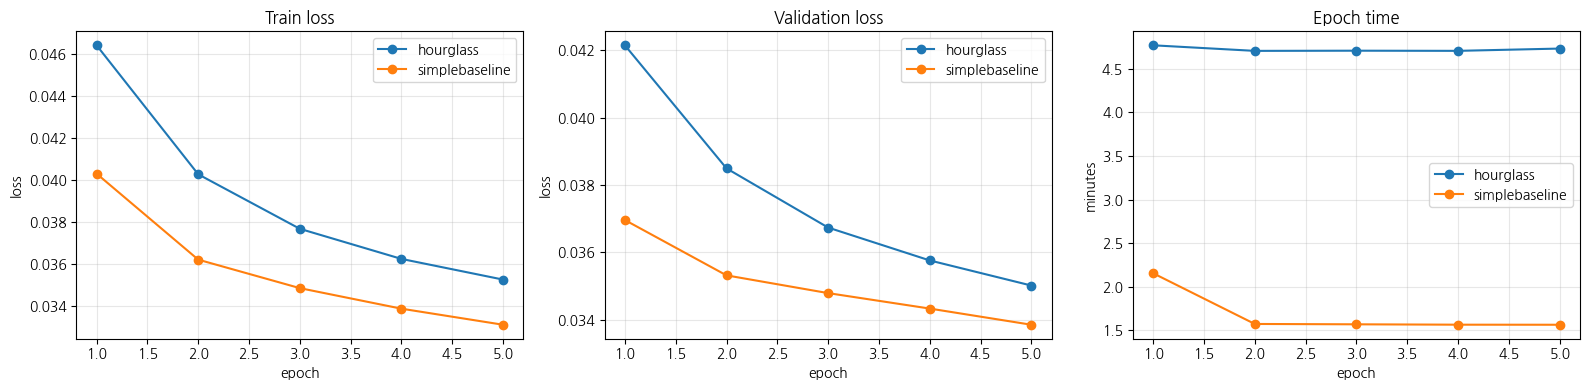

In [34]:
# 학습을 다시 돌리지 않고 저장된 이력만 불러와 비교할 수도 있다.
# hg_history = History.from_json(os.path.join(MODEL_PATH, "hourglass-history.json"))
# sb_history = History.from_json(os.path.join(MODEL_PATH, "simplebaseline-history.json"))

plot_history([hg_history, sb_history])

In [43]:
import pandas as pd

# compute_loss가 stack당 평균(loss / len(outputs))을 반환하므로,
# 두 모델의 loss는 이미 같은 스케일이다. 별도 보정 열을 두지 않는다.
summary = pd.DataFrame({
    "model": ["StackedHourglass", "SimpleBaseline"],
    "params(M)": [count_parameters(hg_trainer.model) / 1e6,
                  count_parameters(sb_trainer.model) / 1e6],
    "final train loss": [hg_history.train_loss[-1], sb_history.train_loss[-1]],
    "best val loss": [min(hg_history.val_loss), min(sb_history.val_loss)],
    "avg epoch(min)": [np.mean(hg_history.epoch_sec) / 60,
                       np.mean(sb_history.epoch_sec) / 60],
})

summary.round(4)

,model,params(M),final train loss,best val loss,avg epoch(min)
0,StackedHourglass,16.2514,0.0352,0.0350,4.7213
1,SimpleBaseline,27.1837,0.0331,0.0339,1.6866


### 5-3. Pose Estimation 결과 시각화 (정성 비교)

In [36]:
# 테스트 이미지 준비 (원하는 사진으로 바꿔도 된다)
!wget -q -O test_image.jpg "https://images.unsplash.com/photo-1546427660-eb346c344ba5?q=80&w=1200"

TEST_IMAGES = ["test_image.jpg"]

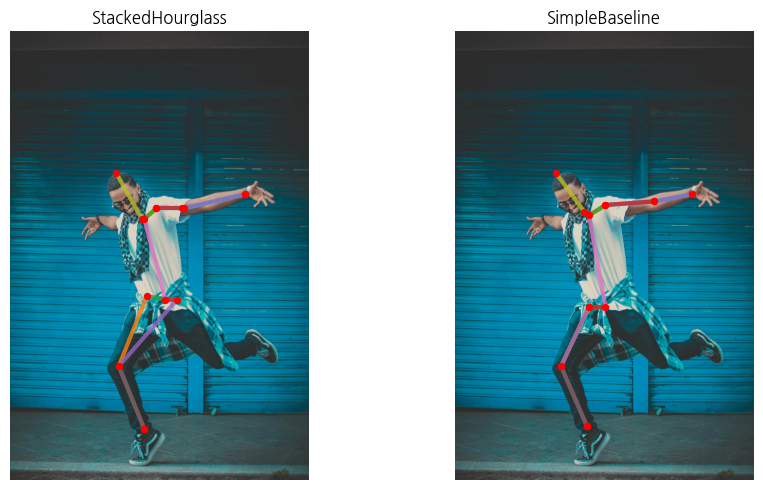

In [37]:
# 각 모델의 best checkpoint 를 불러와 비교
hg_best = build_hourglass(num_heatmap=NUM_HEATMAP).to(DEVICE)
hg_best.load_state_dict(torch.load(hg_history.best_checkpoint, map_location=DEVICE))

sb_best = build_simplebaseline(num_heatmap=NUM_HEATMAP, pretrained=False).to(DEVICE)
sb_best.load_state_dict(torch.load(sb_history.best_checkpoint, map_location=DEVICE))

compare_models({"StackedHourglass": hg_best, "SimpleBaseline": sb_best},
               TEST_IMAGES, threshold=0.0)

In [38]:
# 관절별 신뢰도(heatmap 최대값) 비교 — 어떤 관절에서 갈리는지 확인
_, hg_kp = predict(hg_best, TEST_IMAGES[0])
_, sb_kp = predict(sb_best, TEST_IMAGES[0])

pd.DataFrame({
    "joint": JOINT_NAMES,
    "hourglass score": hg_kp[:, 2].round(3),
    "simplebaseline score": sb_kp[:, 2].round(3),
}).sort_values("simplebaseline score")

,joint,hourglass score,simplebaseline score
5,l_ankle,0.478,0.410
3,l_hip,0.327,0.413
0,r_ankle,0.548,0.422
12,r_shoulder,0.394,0.438
13,l_shoulder,0.432,0.460
2,r_hip,0.381,0.484
7,thorax,0.273,0.489
4,l_knee,0.586,0.527
8,upper_neck,0.320,0.530
9,head_top,0.383,0.534


### 5-4. PCKh@0.5 (정량 평가)

loss는 heatmap 픽셀값의 오차일 뿐이라 "관절을 실제로 맞혔는가"를 재지 못한다.
pose estimation의 표준 지표인 PCKh를 계산해 두 모델을 같은 자로 비교한다.

**PCKh@0.5**: 예측 관절이 정답에서 **머리 크기의 0.5배 이내**면 정답으로 센다.
사람의 크기가 제각각이므로 머리를 기준자로 삼아 정규화하는 것이다.

> ⚠️ **loss 스케일 주의**: 초기 구현의 `compute_loss`는 출력 리스트의 loss를
> 합산했다. Hourglass는 stack 4개, SimpleBaseline은 1개라 두 값을 나란히 놓으면
> 4배 차이가 구조 차이처럼 보였다. 이를 발견해 len(outputs)로 나누도록 수정했다. 재학습이 필요한 것은 Hourglass뿐이라(SimpleBaseline은 출력이 1장이므로 len(outputs)==1, 합산과 평균이 같은 값) Hourglass만 다시 학습했고, 그래서 두 학습 셀의 실행 번호가 이어지지 않는다. 아래 PCKh 표와 5-2의 loss 표 모두 수정 후 기준이다.

In [39]:
class PCKhEvalDataset(Dataset):
    """PCKh 계산용 Dataset. 학습용과 달리 heatmap 대신 정답 좌표를 그대로 반환한다.

    학습 파이프라인과 완전히 같은 crop(margin 0.2 고정) · resize를 거쳐야
    예측 좌표와 정답 좌표가 같은 좌표계에 놓인다.

    Returns:
        image_tensor: (3, 256, 256)
        coords: (16, 2) crop 기준 0~1 정규화 좌표
        vis: (16,) 유효한 관절이면 1
    """

    def __init__(self, annotation_file, image_dir=IMAGE_PATH, limit=None):
        with open(annotation_file, "r") as f:
            raw = json.load(f)
        if limit is not None:
            raw = raw[:limit]
        self.annotations = [parse_annotation(a, image_dir) for a in raw]
        self.pre = Preprocessor(is_train=False)

    def __len__(self):
        return len(self.annotations)

    def __getitem__(self, idx):
        anno = self.annotations[idx]
        image = Image.open(anno["filepath"]).convert("RGB")

        cropped, kp_x, kp_y = self.pre.crop_roi(image, anno, margin=0.2)
        h, w = IMAGE_SIZE
        arr = np.asarray(cropped.resize((w, h), Image.BILINEAR),
                         dtype=np.float32) / 127.5 - 1.0
        image_tensor = torch.from_numpy(arr).permute(2, 0, 1).contiguous()

        vis = np.asarray(anno["joints_vis"], dtype=np.float32).copy()
        vis[(kp_x < 0) | (kp_x > 1) | (kp_y < 0) | (kp_y > 1)] = 0   # crop 밖은 제외
        coords = np.stack([kp_x, kp_y], axis=1).astype(np.float32)

        return image_tensor, coords, vis


@torch.no_grad()
def evaluate_pckh(model, annotation_file, threshold=0.5,
                  batch_size=32, num_workers=NUM_WORKERS, limit=None):
    """검증셋 전체에 대해 관절별 PCKh를 계산한다.

    머리 크기는 upper_neck ~ head_top 거리로 근사한다. 둘 중 하나라도
    보이지 않는 샘플은 기준자를 만들 수 없으므로 평가에서 제외한다.

    Returns:
        (correct, total) — 각각 (16,) ndarray. 관절별 정답 수와 평가 대상 수.
    """
    loader = DataLoader(PCKhEvalDataset(annotation_file, limit=limit),
                        batch_size=batch_size, shuffle=False,
                        num_workers=num_workers, pin_memory=True)
    device = next(model.parameters()).device
    model.eval()

    correct = np.zeros(NUM_HEATMAP)
    total = np.zeros(NUM_HEATMAP)
    skipped = 0

    for images, coords, vis in loader:
        outputs = model(images.to(device, non_blocking=True))
        if not isinstance(outputs, (list, tuple)):
            outputs = [outputs]
        heatmaps = outputs[-1].cpu()          # 마지막 stack이 최종 예측

        coords, vis = coords.numpy(), vis.numpy()
        for b in range(heatmaps.shape[0]):
            gt, v = coords[b], vis[b]
            if v[UPPER_NECK] == 0 or v[HEAD_TOP] == 0:
                skipped += 1
                continue
            head_size = np.linalg.norm(gt[HEAD_TOP] - gt[UPPER_NECK])
            if head_size < 1e-6:
                skipped += 1
                continue

            pred = decode_heatmap(heatmaps[b])[:, :2]
            hit = np.linalg.norm(pred - gt, axis=1) < threshold * head_size

            valid = v > 0
            correct[valid] += hit[valid]
            total[valid] += 1

    print(f"  평가 제외(머리 기준자 없음): {skipped}건")
    return correct, total


print("PCKh 평가 함수 정의 완료")

PCKh 평가 함수 정의 완료


In [40]:
%%time
print("[StackedHourglass]")
hg_correct, hg_total = evaluate_pckh(hg_best, VALID_JSON)
print("[SimpleBaseline]")
sb_correct, sb_total = evaluate_pckh(sb_best, VALID_JSON)

pckh = pd.DataFrame({
    "joint": JOINT_NAMES,
    "n": hg_total.astype(int),
    "hourglass": hg_correct / np.maximum(hg_total, 1) * 100,
    "simplebaseline": sb_correct / np.maximum(sb_total, 1) * 100,
}).round(2)

# 전체 평균은 관절별 표본 수로 가중한다
overall = pd.DataFrame({
    "joint": ["** 전체 (mean) **"],
    "n": [int(hg_total.sum())],
    "hourglass": [hg_correct.sum() / hg_total.sum() * 100],
    "simplebaseline": [sb_correct.sum() / sb_total.sum() * 100],
}).round(2)

pd.concat([pckh, overall], ignore_index=True)

[StackedHourglass]
  평가 제외(머리 기준자 없음): 65건
[SimpleBaseline]
  평가 제외(머리 기준자 없음): 65건
CPU times: user 31.3 s, sys: 1.71 s, total: 33 s
Wall time: 33 s


,joint,n,hourglass,simplebaseline
0,r_ankle,2074,46.91,45.13
1,r_knee,2428,48.81,46.05
2,r_hip,2827,67.46,60.74
3,l_hip,2829,65.64,59.60
4,l_knee,2427,51.83,47.55
5,l_ankle,2080,49.81,47.40
6,pelvis,2821,81.67,85.68
7,thorax,2893,93.29,94.61
8,upper_neck,2893,94.05,94.71
9,head_top,2893,90.77,91.88


### 5-5. 비교 결과 정리

| 항목 | StackedHourglass | SimpleBaseline | 해석 |
| --- | --- | --- | --- |
| 파라미터 수 | 16.25 M | 27.18 M | SimpleBaseline이 1.7배 크다 |
| 1 epoch 소요 시간 | 4.72 분 | 1.69 분 | 파라미터는 1.67배 많은데 2.80배 빠르다. Hourglass는 hourglass 모듈 4개를 순차 통과하며 재귀 깊이 4까지 내려가 실제 연산 그래프가 훨씬 깊기 때문 |
| 최저 val loss | 0.0350 (epoch 5) | 0.0339 (epoch 5) | 3.2% 차이. 이미 stack당 평균이라 그대로 비교 가능 |
| loss 감소 양상 | 5 epoch 내내 완만히 하락, 수렴 전 | 3 epoch 이후 train/val 격차 발생 (0.0331 / 0.0339) | SimpleBaseline이 더 빨리 학습 국면에 진입 |
| 관절별 heatmap 최대값 | thorax 0.273 ~ r_knee 0.604 | l_ankle 0.410 ~ r_knee 0.574 | 편차가 다르나, 두 모델 출력에 sigmoid가 없어 절대 스케일이 달라 **모델 간 직접 비교는 하지 않는다** |

> ⚠️ **loss 스케일 주의(해결됨)**: 초기 구현의 `compute_loss`는 출력 리스트의 loss를 합산해, stack 4개인 Hourglass가 SimpleBaseline보다 4배 큰 값을 냈다. 지금은 `len(outputs)`로 나눠 stack당 평균을 반환하므로 **위 표의 val loss는 이미 같은 스케일**이고 추가 보정 없이 그대로 비교하면 된다.

**논문과 대조할 때 주의할 점**

- 논문에서 SimpleBaseline 은 COCO AP 73.7% 로 당시 SOTA 를 앞섰다.
  다만 그것은 **충분히 수렴한 뒤**의 결과다.
- 5 epoch 수준의 짧은 학습에서는 **ImageNet pretrained encoder** 를 가진
  SimpleBaseline 이 초반 수렴에서 유리할 가능성이 크다.
  Hourglass 는 전부 scratch 학습이기 때문이다.
- 즉 여기서 관측되는 차이에는 "구조의 우열"과 **초기 가중치·학습 예산**의
  영향이 섞여 있다. 결론을 낼 때 이 조건을 함께 밝혀야 한다.

**이번 실험에서 말할 수 있는 것 / 없는 것**

- 말할 수 있는 것 ①: 동일한 5 epoch 예산에서 SimpleBaseline은 **1/3의 시간으로 동등한 수준의 loss**(0.0339 vs 0.0350)에 도달했다. 학습 효율 면에서 뚜렷한 이점이 있다.
- 말할 수 있는 것 ②: **loss와 PCKh가 반대 방향을 가리켰다.** val loss는 SimpleBaseline이 낮은데, 5-4의 PCKh@0.5 전체 평균은 Hourglass 67.63% 대 SimpleBaseline 61.62%로 Hourglass가 6%p 높다. 특히 어깨·팔꿈치 격차가 크다(r_shoulder 72.31 vs 56.10). 가중 MSE가 낮다고 관절을 더 잘 맞히는 것은 아니라는 직접적인 증거다.
- 말할 수 없는 것: "구조의 우열". 두 모델 다 5 epoch로 수렴 전이고, SimpleBaseline만 ImageNet 가중치로 출발했으며 두 모델에 같은 lr 7e-4를 적용했다. 초기 가중치·학습 예산이 구조 효과와 섞여 있다.

---

## 6. 디버깅 기록 및 추가 실험

### 6-1. `[버그]` heatmap → 좌표 복원에서 x/y 뒤바뀜

**발견 경위**: 이 노트북은 256×256 입력에 64×64 정사각형 heatmap만 쓰므로
증상이 드러나지 않는다. 원 논문의 SimpleBaseline 설정(256×192 입력 → 64×48
heatmap)으로 확장하려고 실습 코드를 검토하다 발견한 잠재 버그다.

**원인**: 실습 코드는 평탄화 인덱스를 아래처럼 복원했다.

```python
y = indices // H      # ← 행 개수로 나눔
x = indices - H * y
```

`(H, W)` 텐서를 `reshape(-1)` 하면 인덱스는 `row * W + col` 이므로
**열 개수 W** 로 나눠야 한다. H == W 일 때만 우연히 맞았다.

**수정** (`decode_heatmap`)

```python
ys = idx // w
xs = idx % w
...
return np.stack([xs / w, ys / h, scores], axis=1)   # x는 W, y는 H로 정규화
```

정규화도 원래는 `/ H` 하나로 처리했는데, 축별로 나누도록 함께 고쳤다.

---

### 6-2. `[버그]` crop 밖으로 나간 관절에 정답 heatmap 이 찍힘

**발견 경위**: `Preprocessor`에 랜덤 margin을 넣으면서, 정규화 좌표가 0~1을
벗어날 수 있다는 것을 코드상으로 확인해 발견했다.

**원인**: 학습 시 margin 을 0.1~0.3 랜덤으로 주기 때문에 관절이 crop 밖으로
나갈 수 있다. 정규화 좌표가 0 미만이나 1 초과가 되는데, 실습 코드는 이를
그대로 heatmap 좌표로 반올림해 **경계에 잘못된 정답**을 만들었다.

**수정** (`Preprocessor.__call__`)

```python
vis[(kp_x < 0) | (kp_x > 1) | (kp_y < 0) | (kp_y > 1)] = 0
```

범위를 벗어난 관절은 visibility 0 으로 강등해 heatmap 을 비운다.

---

### 6-3. `[성능]` JPEG 재인코딩 왕복 제거 — 루브릭 1의 핵심

**발견**: 실습의 `Preprocessor` 는 이미 PIL 로 열려 있는 이미지를
`image_to_bytes()` 로 **JPEG 인코딩**한 뒤 `Image.open(BytesIO(...))` 로
**다시 디코딩**했다. `.pt` 파일 경로에서 오던 흐름을 그대로 옮기다 생긴
잔재로 보이는데, 샘플마다 불필요한 인코딩 1회 + 디코딩 1회가 추가된다.

**조치**: `Preprocessor` 가 PIL 이미지를 직접 받도록 바꿨다.
아래 셀에서 대조군과 직접 비교해 효과를 측정한다.

---

### 6-4. `[추가 실험]` Mixed Precision (AMP)

`Trainer(use_amp=True)` 로 fp16 연산을 사용한다. Hourglass 처럼 깊은 모델에서
step 시간과 GPU 메모리를 함께 줄여, 5 epoch 학습을 현실적인 시간에 넣기 위함이다.
loss scaling(`GradScaler`)을 함께 써서 fp16 underflow 를 방지했다.

In [42]:
# 6-3 검증: JPEG 왕복이 있을 때와 없을 때의 전처리 속도 비교
class LegacyPreprocessor(Preprocessor):
    """실습 원본처럼 JPEG 인코딩→디코딩 왕복을 거치는 버전 (비교 대조군)."""

    def __call__(self, image, anno):
        buffer = io.BytesIO()
        image.save(buffer, format="JPEG")                   # ← 불필요한 인코딩
        image = Image.open(io.BytesIO(buffer.getvalue()))   # ← 다시 디코딩
        return super().__call__(image, anno)


def time_preprocess(preprocessor, n=200):
    """단일 프로세스에서 n개 샘플 전처리에 걸리는 시간을 잰다 (ms/sample)."""
    dataset = MPIIDataset(TRAIN_JSON, IMAGE_PATH, preprocessor, limit=n)
    start = time.time()
    for i in range(n):
        dataset[i]
    return (time.time() - start) / n * 1000


legacy_ms = time_preprocess(LegacyPreprocessor(is_train=True))
fast_ms = time_preprocess(Preprocessor(is_train=True))

print(f"원본(JPEG 왕복 O): {legacy_ms:.1f} ms/sample")
print(f"개선(왕복 X)     : {fast_ms:.1f} ms/sample")
print(f"단축률            : {(1 - fast_ms / legacy_ms) * 100:.1f}%")

원본(JPEG 왕복 O): 19.5 ms/sample
개선(왕복 X)     : 12.2 ms/sample
단축률            : 37.2%


---

## 7. 회고

### 배운 점

- **출력 표현이 구조보다 먼저다.** DeepPose 는 좌표를 직접 회귀했고
  Tompson 이 heatmap 으로 바꾸면서 성능이 크게 올랐다. 이번에 직접
  `make_heatmaps` 를 구현해 보니, heatmap 은 라벨의 미세한 흔들림을
  분포로 흡수해 주는 장치라는 점이 코드 수준에서 이해됐다.
- **인터페이스를 맞춰두면 실험이 싸진다.** 두 모델의 `forward()` 반환 형태를
  리스트로 통일한 덕분에 STEP 2 에서 실제로 바꾼 것은 한 줄뿐이었다.
  비교 실험에서 "바뀌지 않은 것"을 보장하는 일이 결과 해석의 전제가 된다.
- **병목은 대개 모델이 아니라 데이터 쪽에 있다.** JPEG 왕복 하나를 없앤 것만으로
  전처리가 19.5 → 12.2 ms/sample (37.2% 단축)이 됐다. 다만 이번 환경은 vCPU 12개라
  num_workers=8로 로딩이 충분히 가려졌고(로딩만 1.0분/epoch), 실제 epoch 시간은
  GPU 연산이 지배했다. 개선의 효과 크기는 환경에 따라 달라진다는 것도 함께 배웠다.
- **집계 방식이 다르면 지표는 비교 대상이 아니다.** 두 모델의 val loss를 나란히
  놓고 "4배 차이"로 읽을 뻔했다. 초기 구현에서 Hourglass는 stack 4개 loss가 합산된 값이었고, compute_loss가 stack당 평균을 내도록 고치고 나니 두 모델의 최저 val loss는 0.0350 대 0.0339, 3.2% 차이였다. 숫자를 비교하기 전에 그 숫자가 어떻게
  만들어졌는지 확인해야 한다.

### 아쉬운 점

- **PCKh 기준자를 근사로 대체했다.** 5-4에서 PCKh@0.5를 구현했지만, 머리 크기를 MPII 공식 정의(head rect 대각선 × 0.6) 대신 upper_neck~head_top 거리로 근사했다. 방향은 맞지만 논문 수치와 직접 비교할 수 있는 값은 아니다. 또 좌표가 crop 정규화 공간이라 원본 종횡비가 왜곡된 상태에서 거리를 잰다.
- **학습 예산이 짧다.** 5 epoch 은 두 모델 모두 수렴 전이고, SimpleBaseline 은
  ImageNet pretrained encoder 를 쓰는 반면 Hourglass 는 scratch 다.
  공정한 비교라기보다 "동일 예산에서의 초기 수렴 속도 비교"에 가깝다.
- **augmentation 이 margin 랜덤 하나뿐이다.** 원 논문들은 flip, rotation,
  scale jitter 를 쓴다. 특히 좌우 flip 은 관절 인덱스도 함께 swap 해야 해서
  구현 난이도가 있는데, 이 부분을 넣지 못했다.

### 느낀 점

논문의 수치를 그대로 옮겨 "SimpleBaseline 이 더 좋다"고 적기는 쉽지만,
내 실험 조건에서 그 문장이 성립하는지는 별개의 문제였다. pretrained 여부와
학습 예산이라는 조건을 빼놓고 결론을 적었다면 틀린 주장이 됐을 것이다.
결과보다 **결과가 성립하는 조건**을 함께 적는 습관이 필요하다고 느꼈다.

### 다음에 해볼 것

1. PCKh 기준자를 MPII 공식 정의(head rect 대각선 × 0.6)로 바꿔 논문 수치와 대조
2. Hourglass 도 동일하게 20 epoch 이상 학습해 수렴 후 비교
3. backbone 을 resnet18/34 로 바꿔 정확도-속도 트레이드오프 측정
4. flip augmentation + flip test (좌우 반전 예측 평균) 적용